# 08_residual_diagnostics_and_operating_regimes.ipynb

## Σκοπός του notebook

Το παρόν notebook αποτελεί το **strict downstream diagnostics stage** του current forecasting-first pipeline.

Ο στόχος του δεν είναι να εισαγάγει νέα μοντέλα ή να αλλάξει το benchmark protocol, αλλά να αναλύσει αν τα residuals των ήδη υλοποιημένων baseline models εμφανίζουν **δομημένη εξάρτηση από operating regimes**.

Η ανάλυση αυτή λειτουργεί ως καθαρή γέφυρα:

**forecasting -> residual diagnostics -> health-aware / PHM-aware interpretation**

## Σχέση με το thesis framing

Το notebook **δεν αντικαθιστά** το forecasting / digital twin framing της εργασίας.  
Αντίθετα, το ενισχύει, δείχνοντας ότι ένα forecasting-first και digital-twin-aware pipeline γίνεται πιο ακαδημαϊκά ισχυρό όταν συνοδεύεται από:

- residual structure analysis,
- operating-regime dependence,
- και προσεκτική health-oriented interpretation.

## Τι δεν κάνει αυτό το notebook

Το notebook αυτό δεν:

- εκπαιδεύει νέα μοντέλα,
- δεν επαναορίζει train / validation / test splits,
- δεν αλλάζει feature engineering upstream,
- δεν κάνει fault diagnosis,
- δεν παρουσιάζει anomaly detection ως completed module,
- δεν κάνει RUL estimation,
- και δεν ισχυρίζεται ότι υπάρχει ήδη validated PHM system.

## Canonical downstream contract

Το `NB08` καταναλώνει μόνο canonical exported artifacts από τα upstream notebooks:

- `test_final.csv`
- `baseline_metrics.csv`
- `nb06_test_predictions.csv`
- `nb07_all_test_predictions_long.csv` ή, εναλλακτικά, τα individual NB07 prediction exports

Άρα το `NB08` λειτουργεί ως:

- **test-only diagnostics notebook**
- πάνω στο ήδη καθορισμένο benchmark stack
- χωρίς contamination του canonical benchmark artifact
- και χωρίς upstream scope expansion

In [1]:
# ============================================================
# NB08 | Imports και display setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Προαιρετικά: κρατάμε το output πιο καθαρό
warnings.filterwarnings("ignore")

# Βασικό visual style για thesis-ready plots
sns.set_theme(style="whitegrid", context="talk")

# Display options για πιο καθαρούς πίνακες
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.6f}".format)

print("NB08 environment initialized successfully.")

NB08 environment initialized successfully.


In [2]:
# ============================================================
# NB08 | Path helpers
# ============================================================

def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το project root ανεβαίνοντας από το current working directory.

    Απαιτούμε να υπάρχουν τουλάχιστον:
    - data/
    - notebooks/
    """
    current = start_path.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Δεν βρέθηκε project root με φακέλους 'data/' και 'notebooks/'."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
PREDICTIONS_DIR = DATA_PROCESSED / "predictions"
DIAGNOSTICS_DIR = DATA_PROCESSED / "diagnostics"

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_PROCESSED = {DATA_PROCESSED}")

PROJECT_ROOT = C:\Users\diony\Desktop\WindPower_DigitalTwin
DATA_PROCESSED = C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed


In [3]:
# ============================================================
# NB08 | Constants και canonical paths
# ============================================================

TEST_PATH = DATA_PROCESSED / "test_final.csv"
BENCHMARK_PATH = DATA_PROCESSED / "baseline_metrics.csv"
NB06_PRED_PATH = DATA_PROCESSED / "nb06_test_predictions.csv"

# NB07 canonical long export
NB07_ALL_PRED_PATH = PREDICTIONS_DIR / "nb07_all_test_predictions_long.csv"

# NB07 fallback individual exports
NB07_RF_PRED_PATH = PREDICTIONS_DIR / "nb07_random_forest_test_predictions.csv"
NB07_XGB_PRED_PATH = PREDICTIONS_DIR / "nb07_xgboost_test_predictions.csv"
NB07_MLP_PRED_PATH = PREDICTIONS_DIR / "nb07_mlp_test_predictions.csv"

PARK_ID_COLUMN = "park_id"
TIMESTAMP_COLUMN = "timestamp"
FLAG_COLUMN = "test_flag"
TARGET_COLUMN = "Power_Output_Normalized"
BASELINE_COLUMN = "Baseline_Prediction"

CANONICAL_BENCHMARK_COLUMNS = ["Model", "MAE", "RMSE", "R2"]
EXPECTED_MODELS = [
    "Persistence",
    "Linear Regression",
    "Random Forest",
    "XGBoost",
    "MLP",
]

REQUIRED_TEST_COLUMNS = {
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    FLAG_COLUMN,
    TARGET_COLUMN,
    "Wind_Speed_100m_ms",
    "ws_ref",
    "hour",
    "month",
}

REQUIRED_PRED_COLUMNS = {
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    "model",
    "y_true",
    "y_pred",
}

print("Canonical constants defined.")

Canonical constants defined.


In [4]:
# ============================================================
# NB08 | Core loading / validation utilities
# ============================================================

def standardize_park_id(series: pd.Series) -> pd.Series:
    """
    Μετατρέπει park_id σε zero-padded string για deterministic joins.
    """
    return (
        series.astype("string")
        .str.strip()
        .str.replace(".0", "", regex=False)
        .str.zfill(5)
    )


def parse_timestamp_strict(series: pd.Series, column_name: str) -> pd.Series:
    """
    Strict datetime parsing για downstream notebooks.
    """
    parsed = pd.to_datetime(series, errors="coerce", format="%Y-%m-%d %H:%M:%S")

    if parsed.isna().any():
        bad_count = int(parsed.isna().sum())
        raise ValueError(
            f"Αποτυχία strict datetime parsing στη στήλη '{column_name}'. "
            f"NaT count = {bad_count}"
        )

    return parsed


def assert_required_columns(df: pd.DataFrame, required_columns, df_name: str) -> None:
    """
    Fail-fast έλεγχος required columns.
    """
    missing = sorted(set(required_columns) - set(df.columns))
    if missing:
        raise KeyError(
            f"Το dataframe '{df_name}' λείπουν required columns: {missing}"
        )


def assert_unique_keys(
    df: pd.DataFrame,
    key_cols,
    df_name: str,
) -> None:
    """
    Ελέγχει ότι τα key columns είναι unique.
    """
    dup_count = int(df.duplicated(key_cols).sum())
    if dup_count > 0:
        raise ValueError(
            f"Βρέθηκαν {dup_count} duplicate rows στο '{df_name}' "
            f"πάνω στα keys {key_cols}."
        )


def load_test_artifact(csv_path: Path) -> pd.DataFrame:
    """
    Φορτώνει το canonical test split με strict downstream contract.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"Λείπει το required file: {csv_path}")

    df = pd.read_csv(csv_path)
    assert_required_columns(df, REQUIRED_TEST_COLUMNS, "test_final")

    df[PARK_ID_COLUMN] = standardize_park_id(df[PARK_ID_COLUMN])
    df[TIMESTAMP_COLUMN] = parse_timestamp_strict(df[TIMESTAMP_COLUMN], TIMESTAMP_COLUMN)

    assert_unique_keys(df, [PARK_ID_COLUMN, TIMESTAMP_COLUMN], "test_final")

    # Deterministic ordering
    df = df.sort_values([PARK_ID_COLUMN, TIMESTAMP_COLUMN], kind="mergesort").reset_index(drop=True)

    return df


def load_prediction_export(csv_path: Path, export_name: str) -> pd.DataFrame:
    """
    Φορτώνει prediction export με canonical schema.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"Λείπει το required prediction export: {csv_path}")

    df = pd.read_csv(csv_path)
    assert_required_columns(df, REQUIRED_PRED_COLUMNS, export_name)

    df[PARK_ID_COLUMN] = standardize_park_id(df[PARK_ID_COLUMN])
    df[TIMESTAMP_COLUMN] = parse_timestamp_strict(df[TIMESTAMP_COLUMN], TIMESTAMP_COLUMN)

    # Null checks
    null_total = int(df[list(REQUIRED_PRED_COLUMNS)].isna().sum().sum())
    if null_total > 0:
        raise ValueError(
            f"Βρέθηκαν null values στο prediction export '{export_name}'. "
            f"Null total = {null_total}"
        )

    assert_unique_keys(
        df,
        [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model"],
        export_name,
    )

    df = df.sort_values(
        [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model"],
        kind="mergesort"
    ).reset_index(drop=True)

    return df


def load_benchmark_artifact(csv_path: Path) -> pd.DataFrame:
    """
    Φορτώνει το canonical benchmark artifact.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"Λείπει το benchmark artifact: {csv_path}")

    df = pd.read_csv(csv_path)

    if list(df.columns) != CANONICAL_BENCHMARK_COLUMNS:
        raise ValueError(
            "Το baseline_metrics.csv δεν έχει canonical schema. "
            f"Expected={CANONICAL_BENCHMARK_COLUMNS}, found={list(df.columns)}"
        )

    if df["Model"].duplicated().any():
        dup_models = df.loc[df["Model"].duplicated(), "Model"].tolist()
        raise ValueError(f"Duplicate model rows στο benchmark artifact: {dup_models}")

    return df.copy()

In [5]:
# ============================================================
# NB08 | NB07 prediction loading with fallback logic
# ============================================================

def load_nb07_predictions() -> pd.DataFrame:
    """
    Προτιμά το canonical NB07 long export.
    Αν λείπει, δοκιμάζει fallback στα individual exports.
    """
    if NB07_ALL_PRED_PATH.exists():
        nb07_df = load_prediction_export(NB07_ALL_PRED_PATH, "nb07_all_test_predictions_long")

        expected_nb07_models = {"Random Forest", "XGBoost", "MLP"}
        found_nb07_models = set(nb07_df["model"].astype(str).unique())

        if found_nb07_models != expected_nb07_models:
            raise ValueError(
                "Το NB07 long export δεν έχει τα αναμενόμενα model names. "
                f"Expected={sorted(expected_nb07_models)}, found={sorted(found_nb07_models)}"
            )

        return nb07_df

    # Fallback στα individual exports
    fallback_paths = {
        "Random Forest": NB07_RF_PRED_PATH,
        "XGBoost": NB07_XGB_PRED_PATH,
        "MLP": NB07_MLP_PRED_PATH,
    }

    missing_exports = [
        f"{model}: {path}" for model, path in fallback_paths.items() if not path.exists()
    ]
    if missing_exports:
        raise FileNotFoundError(
            "Δεν βρέθηκε ούτε το canonical NB07 long export ούτε όλα τα fallback individual exports.\n"
            + "\n".join(missing_exports)
        )

    dfs = []
    for model_name, export_path in fallback_paths.items():
        pred_df = load_prediction_export(export_path, f"NB07 {model_name}")
        found_models = set(pred_df["model"].astype(str).unique())

        if found_models != {model_name}:
            raise ValueError(
                f"Το export '{export_path.name}' δεν περιέχει μόνο το model '{model_name}'. "
                f"Found={sorted(found_models)}"
            )

        dfs.append(pred_df)

    nb07_df = pd.concat(dfs, axis=0, ignore_index=True)
    nb07_df = nb07_df.sort_values(
        [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model"],
        kind="mergesort"
    ).reset_index(drop=True)

    return nb07_df

## Γιατί προηγείται provenance / integrity audit

Πριν αναλυθούν residuals και operating regimes, πρέπει να επιβεβαιωθεί ότι:

- όλα τα prediction exports αναφέρονται στο ίδιο canonical test backbone,
- δεν λείπουν observations,
- δεν υπάρχουν duplicate keys,
- τα `y_true` των exports συμφωνούν με το canonical target του `test_final.csv`,
- και δεν υπάρχει benchmark contamination ή mismatch ανά model.

Το `NB08` πρέπει να αποτυγχάνει νωρίς αν ο downstream handoff από τα `NB05`, `NB06`, `NB07` δεν είναι πλήρως συνεπής.

In [6]:
# ============================================================
# NB08 | Load canonical artifacts
# ============================================================

test_df = load_test_artifact(TEST_PATH)
benchmark_df = load_benchmark_artifact(BENCHMARK_PATH)
nb06_pred_df = load_prediction_export(NB06_PRED_PATH, "nb06_test_predictions")
nb07_pred_df = load_nb07_predictions()

print("Loaded artifacts successfully.")
print(f"test_final shape              : {test_df.shape}")
print(f"baseline_metrics shape        : {benchmark_df.shape}")
print(f"nb06_test_predictions shape   : {nb06_pred_df.shape}")
print(f"nb07_predictions shape        : {nb07_pred_df.shape}")

Loaded artifacts successfully.
test_final shape              : (1086336, 47)
baseline_metrics shape        : (5, 4)
nb06_test_predictions shape   : (2172672, 5)
nb07_predictions shape        : (3259008, 5)


In [7]:
# ============================================================
# NB08 | Quick artifact audit
# ============================================================

artifact_audit = pd.DataFrame(
    [
        {
            "artifact": "test_final.csv",
            "rows": len(test_df),
            "cols": test_df.shape[1],
            "unique_parks": test_df[PARK_ID_COLUMN].nunique(),
            "timestamp_min": test_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": test_df[TIMESTAMP_COLUMN].max(),
        },
        {
            "artifact": "nb06_test_predictions.csv",
            "rows": len(nb06_pred_df),
            "cols": nb06_pred_df.shape[1],
            "unique_models": nb06_pred_df["model"].nunique(),
            "timestamp_min": nb06_pred_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": nb06_pred_df[TIMESTAMP_COLUMN].max(),
        },
        {
            "artifact": "nb07_predictions",
            "rows": len(nb07_pred_df),
            "cols": nb07_pred_df.shape[1],
            "unique_models": nb07_pred_df["model"].nunique(),
            "timestamp_min": nb07_pred_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": nb07_pred_df[TIMESTAMP_COLUMN].max(),
        },
    ]
)

artifact_audit

,artifact,rows,cols,unique_parks,timestamp_min,timestamp_max,unique_models
0,test_final.csv,1086336,47,256.000000,2019-12-01 01:00:00,2020-06-01 23:00:00,NaN
1,nb06_test_predictions.csv,2172672,5,NaN,2019-12-01 01:00:00,2020-06-01 23:00:00,2.000000
2,nb07_predictions,3259008,5,NaN,2019-12-01 01:00:00,2020-06-01 23:00:00,3.000000


In [8]:
# ============================================================
# NB08 | Build canonical evaluation space
# ============================================================

# Συνένωση NB06 + NB07 prediction exports
all_pred_df = pd.concat([nb06_pred_df, nb07_pred_df], axis=0, ignore_index=True)

# Deterministic sort
all_pred_df = all_pred_df.sort_values(
    [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model"],
    kind="mergesort"
).reset_index(drop=True)

# Strict model set check
found_models = list(pd.unique(all_pred_df["model"]))
missing_models = sorted(set(EXPECTED_MODELS) - set(found_models))
unknown_models = sorted(set(found_models) - set(EXPECTED_MODELS))

if missing_models:
    raise ValueError(f"Λείπουν models από το combined prediction space: {missing_models}")
if unknown_models:
    raise ValueError(f"Βρέθηκαν unknown models στο combined prediction space: {unknown_models}")

print("Combined prediction space constructed successfully.")
print(f"Combined rows = {len(all_pred_df):,}")
print(f"Models        = {sorted(found_models)}")

Combined prediction space constructed successfully.
Combined rows = 5,431,680
Models        = ['Linear Regression', 'MLP', 'Persistence', 'Random Forest', 'XGBoost']


In [9]:
# ============================================================
# NB08 | Exact key-space integrity checks
# ============================================================

test_key_df = test_df[[PARK_ID_COLUMN, TIMESTAMP_COLUMN]].copy()
test_key_df["__key__"] = (
    test_key_df[PARK_ID_COLUMN].astype(str) + "||" +
    test_key_df[TIMESTAMP_COLUMN].dt.strftime("%Y-%m-%d %H:%M:%S")
)

test_keys = set(test_key_df["__key__"])
expected_rows_per_model = len(test_df)

coverage_rows = []
for model_name, model_df in all_pred_df.groupby("model", observed=True):
    model_key = (
        model_df[PARK_ID_COLUMN].astype(str) + "||" +
        model_df[TIMESTAMP_COLUMN].dt.strftime("%Y-%m-%d %H:%M:%S")
    )
    model_keys = set(model_key)

    missing_key_count = len(test_keys - model_keys)
    extra_key_count = len(model_keys - test_keys)

    if len(model_df) != expected_rows_per_model:
        raise ValueError(
            f"Το model '{model_name}' δεν έχει ακριβώς {expected_rows_per_model:,} rows. "
            f"Found={len(model_df):,}"
        )

    if missing_key_count > 0:
        raise ValueError(
            f"Το model '{model_name}' λείπουν {missing_key_count} test keys."
        )

    if extra_key_count > 0:
        raise ValueError(
            f"Το model '{model_name}' έχει {extra_key_count} extra keys εκτός canonical test space."
        )

    coverage_rows.append(
        {
            "model": model_name,
            "rows": len(model_df),
            "missing_keys": missing_key_count,
            "extra_keys": extra_key_count,
        }
    )

coverage_audit_df = pd.DataFrame(coverage_rows).sort_values("model").reset_index(drop=True)
coverage_audit_df

,model,rows,missing_keys,extra_keys
0,Linear Regression,1086336,0,0
1,MLP,1086336,0,0
2,Persistence,1086336,0,0
3,Random Forest,1086336,0,0
4,XGBoost,1086336,0,0


In [10]:
# ============================================================
# NB08 | y_true consistency check against canonical target
# ============================================================

canonical_target_df = test_df[[PARK_ID_COLUMN, TIMESTAMP_COLUMN, TARGET_COLUMN]].copy()

merged_truth_check = all_pred_df.merge(
    canonical_target_df,
    on=[PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    how="left",
    validate="many_to_one",
)

if merged_truth_check[TARGET_COLUMN].isna().any():
    raise ValueError("Βρέθηκαν prediction rows που δεν ταιριάζουν με canonical test target rows.")

truth_diff = np.abs(
    merged_truth_check["y_true"].to_numpy() -
    merged_truth_check[TARGET_COLUMN].to_numpy()
)

max_truth_diff = float(np.max(truth_diff))
if max_truth_diff > 1e-12:
    raise ValueError(
        "Τα prediction exports δεν συμφωνούν με το canonical target του test split. "
        f"Max abs diff = {max_truth_diff}"
    )

print("Prediction y_true values are fully consistent with test_final target values.")
print(f"Max absolute difference = {max_truth_diff:.12f}")

Prediction y_true values are fully consistent with test_final target values.
Max absolute difference = 0.000000000000


## Benchmark context

Το `baseline_metrics.csv` αντιμετωπίζεται εδώ ως **read-only benchmark context**.

Το `NB08`:

- δεν τροποποιεί benchmark rows,
- δεν ξαναϋπολογίζει final ranking για thesis reporting,
- και δεν χρησιμοποιεί validation metrics για νέα επιλογή μοντέλου.

Η συμβολή του notebook είναι διαφορετική:

από το ερώτημα  
**"ποιο μοντέλο είναι συνολικά καλύτερο;"**

στο ερώτημα  
**"πού και υπό ποιες operating conditions αποτυγχάνει κάθε μοντέλο;"**

In [11]:
# ============================================================
# NB08 | Canonical benchmark context
# ============================================================

benchmark_ranked = benchmark_df.sort_values("MAE", kind="mergesort").reset_index(drop=True)
benchmark_ranked["rank_by_mae"] = np.arange(1, len(benchmark_ranked) + 1)

# Χρήσιμο model order για plots
model_order = benchmark_ranked["Model"].tolist()

best_overall_model = benchmark_ranked.loc[0, "Model"]
linear_reference_model = "Linear Regression"

print(f"Best overall model according to current benchmark artifact: {best_overall_model}")
benchmark_ranked

Best overall model according to current benchmark artifact: XGBoost


,Model,MAE,RMSE,R2,rank_by_mae
0,XGBoost,0.065750,0.113494,0.860348,1
1,MLP,0.068008,0.115343,0.855760,2
2,Persistence,0.069832,0.130409,0.815620,3
3,Random Forest,0.070963,0.118826,0.846918,4
4,Linear Regression,0.072721,0.120307,0.843077,5


In [12]:
# ============================================================
# NB08 | Join predictions with canonical test backbone
# ============================================================

diagnostic_columns = [
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    TARGET_COLUMN,
    FLAG_COLUMN,
    BASELINE_COLUMN,
    "Wind_Speed_100m_ms",
    "ws_ref",
    "hour",
    "month",
    "hub_height_m",
    "nominal_power_kW",
    "turbine",
]

analysis_df = all_pred_df.merge(
    test_df[diagnostic_columns],
    on=[PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    how="left",
    validate="many_to_one",
)

# Fail-fast null check μετά το join
joined_null_total = int(analysis_df[diagnostic_columns].isna().sum().sum())
if joined_null_total > 0:
    raise ValueError(
        f"Βρέθηκαν null values μετά το join με το canonical test backbone. Null total={joined_null_total}"
    )

# Residual features
analysis_df["residual"] = analysis_df["y_true"] - analysis_df["y_pred"]
analysis_df["abs_error"] = analysis_df["residual"].abs()
analysis_df["squared_error"] = analysis_df["residual"] ** 2
analysis_df["signed_error"] = analysis_df["residual"]

# Assertion ότι είμαστε πράγματι σε test-only space
flag_values = set(analysis_df[FLAG_COLUMN].astype(int).unique().tolist())
if flag_values != {1}:
    raise ValueError(
        f"Το analysis dataframe δεν είναι test-only. Found test_flag values = {flag_values}"
    )

print("Analysis dataframe created successfully.")
print(analysis_df.shape)
analysis_df.head()

Analysis dataframe created successfully.
(5431680, 19)


,park_id,timestamp,model,y_true,y_pred,Power_Output_Normalized,test_flag,Baseline_Prediction,Wind_Speed_100m_ms,ws_ref,hour,month,hub_height_m,nominal_power_kW,turbine,residual,abs_error,squared_error,signed_error
0,00011,2019-12-01 01:00:00,Linear Regression,0.004000,0.021606,0.004000,1,0.000000,1.005492,0.930141,1,12,84,"2,350.000000","E-82 E4 (2,35MW)",-0.017606,0.017606,0.000310,-0.017606
1,00011,2019-12-01 01:00:00,MLP,0.004000,0.028347,0.004000,1,0.000000,1.005492,0.930141,1,12,84,"2,350.000000","E-82 E4 (2,35MW)",-0.024347,0.024347,0.000593,-0.024347
2,00011,2019-12-01 01:00:00,Persistence,0.004000,0.027000,0.004000,1,0.000000,1.005492,0.930141,1,12,84,"2,350.000000","E-82 E4 (2,35MW)",-0.023000,0.023000,0.000529,-0.023000
3,00011,2019-12-01 01:00:00,Random Forest,0.004000,0.019711,0.004000,1,0.000000,1.005492,0.930141,1,12,84,"2,350.000000","E-82 E4 (2,35MW)",-0.015711,0.015711,0.000247,-0.015711
4,00011,2019-12-01 01:00:00,XGBoost,0.004000,0.024364,0.004000,1,0.000000,1.005492,0.930141,1,12,84,"2,350.000000","E-82 E4 (2,35MW)",-0.020364,0.020364,0.000415,-0.020364


## Ορισμός operating regimes

Τα operating regimes ορίζονται με βάση τις **πραγματοποιημένες operating conditions** του canonical test backbone και όχι με βάση τις model predictions.

### Wind-related regimes
Οι wind regimes χρησιμοποιούνται ως **park-agnostic operating proxies**.  
Δεν πρέπει να ερμηνεύονται ως ακριβή turbine control-state labels.

### Power-related regimes
Οι power regimes ορίζονται πάνω στο realized target (`y_true` / `Power_Output_Normalized`) ώστε να μελετηθεί αν το forecasting error μεταβάλλεται με το πραγματικό output level.

### Temporal regimes
Τα temporal regimes παραμένουν **δευτερεύουσα diagnostic slice** και όχι το primary operating-regime definition.

In [13]:
# ============================================================
# NB08 | Operating regime definitions
# ============================================================

# -----------------------------
# Wind-related regimes
# -----------------------------
wind_bins = [0.0, 3.0, 6.0, 9.0, 12.0, 15.0, np.inf]
wind_labels = [
    "very_low_<3",
    "low_3_6",
    "medium_6_9",
    "transition_9_12",
    "high_12_15",
    "very_high_15_plus",
]

analysis_df["wind_regime"] = pd.cut(
    analysis_df["Wind_Speed_100m_ms"],
    bins=wind_bins,
    labels=wind_labels,
    right=False,
    include_lowest=True,
    ordered=True,
)

# -----------------------------
# Power-related regimes
# -----------------------------
power_bins = [0.0, 0.05, 0.25, 0.50, 0.75, np.inf]
power_labels = [
    "near_zero_0_0.05",
    "low_output_0.05_0.25",
    "medium_output_0.25_0.50",
    "high_output_0.50_0.75",
    "near_rated_0.75_plus",
]

analysis_df["power_regime"] = pd.cut(
    analysis_df["y_true"],
    bins=power_bins,
    labels=power_labels,
    right=False,
    include_lowest=True,
    ordered=True,
)

# -----------------------------
# Temporal regimes (secondary)
# -----------------------------
def map_hour_block(hour: int) -> str:
    if 0 <= hour <= 5:
        return "night_00_05"
    if 6 <= hour <= 11:
        return "morning_06_11"
    if 12 <= hour <= 17:
        return "afternoon_12_17"
    if 18 <= hour <= 23:
        return "evening_18_23"
    raise ValueError(f"Μη έγκυρη ώρα: {hour}")

analysis_df["time_block"] = analysis_df["hour"].astype(int).map(map_hour_block)

# Ordered categorical dtype για deterministic plotting
analysis_df["time_block"] = pd.Categorical(
    analysis_df["time_block"],
    categories=["night_00_05", "morning_06_11", "afternoon_12_17", "evening_18_23"],
    ordered=True,
)

print("Operating regimes defined successfully.")

Operating regimes defined successfully.


In [14]:
# ============================================================
# NB08 | Regime coverage audit
# ============================================================

wind_regime_counts = (
    analysis_df[["wind_regime"]]
    .value_counts(dropna=False)
    .rename("count")
    .reset_index()
)
wind_regime_counts["share"] = wind_regime_counts["count"] / wind_regime_counts["count"].sum()

power_regime_counts = (
    analysis_df[["power_regime"]]
    .value_counts(dropna=False)
    .rename("count")
    .reset_index()
)
power_regime_counts["share"] = power_regime_counts["count"] / power_regime_counts["count"].sum()

time_block_counts = (
    analysis_df[["time_block"]]
    .value_counts(dropna=False)
    .rename("count")
    .reset_index()
)
time_block_counts["share"] = time_block_counts["count"] / time_block_counts["count"].sum()

print("Wind regime coverage")
display(wind_regime_counts)

print("Power regime coverage")
display(power_regime_counts)

print("Time-block coverage")
display(time_block_counts)

Wind regime coverage


,wind_regime,count,share
0,low_3_6,1308960,0.240986
1,medium_6_9,1254890,0.231032
2,very_low_<3,1192635,0.219570
3,transition_9_12,952010,0.175270
4,high_12_15,458390,0.084392
5,very_high_15_plus,264795,0.048750


Power regime coverage


,power_regime,count,share
0,near_zero_0_0.05,2420190,0.445569
1,low_output_0.05_0.25,1475535,0.271654
2,near_rated_0.75_plus,608140,0.111962
3,medium_output_0.25_0.50,605010,0.111385
4,high_output_0.50_0.75,322805,0.059430


Time-block coverage


,time_block,count,share
0,afternoon_12_17,1358770,0.250156
1,evening_18_23,1358540,0.250114
2,morning_06_11,1357990,0.250013
3,night_00_05,1356380,0.249716


## Cross-model error structure

Πριν περάσουμε στα operating regimes, είναι χρήσιμο να εξετάσουμε αν τα διαφορετικά models αποτυγχάνουν στις ίδιες observations ή σε διαφορετικές περιοχές του test space.

Αν η residual / abs-error structure είναι ισχυρά κοινή across models, τότε μέρος της forecasting δυσκολίας φαίνεται να είναι intrinsic στο operating space.  
Αν η error structure διαφοροποιείται ουσιαστικά μεταξύ μοντέλων, τότε η δυσκολία είναι εν μέρει model-specific.

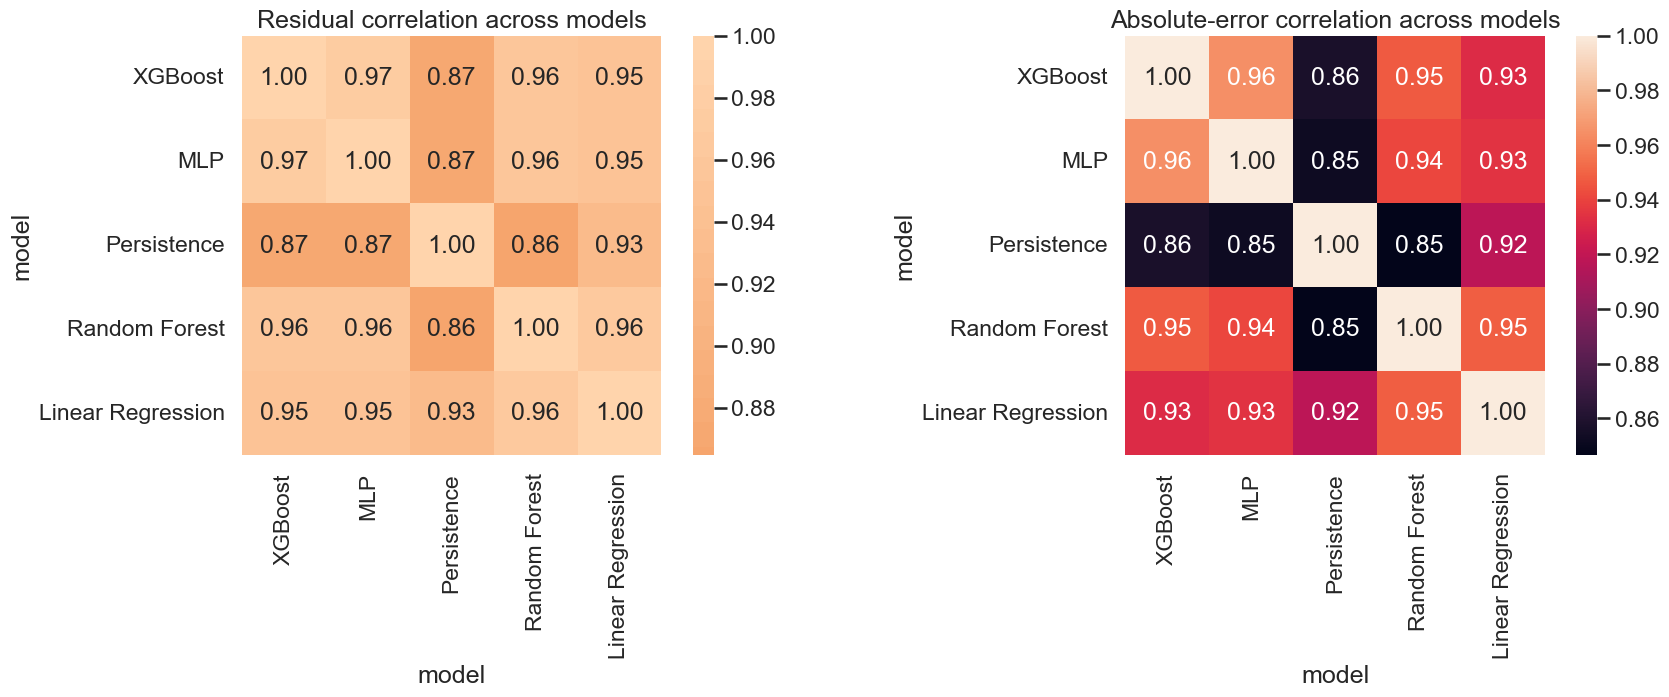

In [15]:
# ============================================================
# NB08 | Cross-model error structure
# ============================================================

# Wide matrices με κοινό row-level evaluation space
residual_wide = analysis_df.pivot(
    index=[PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    columns="model",
    values="residual",
)

abs_error_wide = analysis_df.pivot(
    index=[PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    columns="model",
    values="abs_error",
)

# Deterministic column order με βάση το benchmark ranking
residual_wide = residual_wide[model_order]
abs_error_wide = abs_error_wide[model_order]

residual_corr = residual_wide.corr()
abs_error_corr = abs_error_wide.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    residual_corr,
    annot=True,
    fmt=".2f",
    center=0.0,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Residual correlation across models")

sns.heatmap(
    abs_error_corr,
    annot=True,
    fmt=".2f",
    square=True,
    ax=axes[1],
)
axes[1].set_title("Absolute-error correlation across models")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# NB08 | Aggregation helper
# ============================================================

def summarize_by_regime(
    df: pd.DataFrame,
    regime_col: str,
) -> pd.DataFrame:
    """
    Συνοψίζει residual behavior ανά model και regime.
    """
    summary = (
        df.groupby(["model", regime_col], observed=True)
        .agg(
            count=("residual", "size"),
            mean_residual=("residual", "mean"),
            median_residual=("residual", "median"),
            mae=("abs_error", "mean"),
            mse=("squared_error", "mean"),
        )
        .reset_index()
    )

    summary["rmse"] = np.sqrt(summary["mse"])
    summary = summary.drop(columns=["mse"])

    # Για deterministic παρουσιάσεις
    summary["model"] = pd.Categorical(
        summary["model"],
        categories=model_order,
        ordered=True,
    )
    summary = summary.sort_values(["model", regime_col], kind="mergesort").reset_index(drop=True)

    return summary

In [17]:
# ============================================================
# NB08 | Wind-regime summaries
# ============================================================

wind_summary_df = summarize_by_regime(analysis_df, "wind_regime")
wind_summary_df.head(15)

,model,wind_regime,count,mean_residual,median_residual,mae,rmse
0,XGBoost,very_low_<3,238527,-0.000507,-0.002429,0.021864,0.055706
1,XGBoost,low_3_6,261792,-0.000035,-0.005992,0.041806,0.078855
2,XGBoost,medium_6_9,250978,-0.000667,-0.010576,0.070959,0.113073
3,XGBoost,transition_9_12,190402,-0.000569,-0.011600,0.109500,0.153881
4,XGBoost,high_12_15,91678,-0.002692,0.004308,0.127840,0.173796
5,XGBoost,very_high_15_plus,52959,0.003240,0.010132,0.092302,0.146609
6,MLP,very_low_<3,238527,-0.001780,-0.004598,0.023217,0.056358
7,MLP,low_3_6,261792,-0.000396,-0.007191,0.043222,0.080006
8,MLP,medium_6_9,250978,0.001665,-0.009170,0.072051,0.114610
9,MLP,transition_9_12,190402,0.006853,-0.006094,0.111595,0.156152


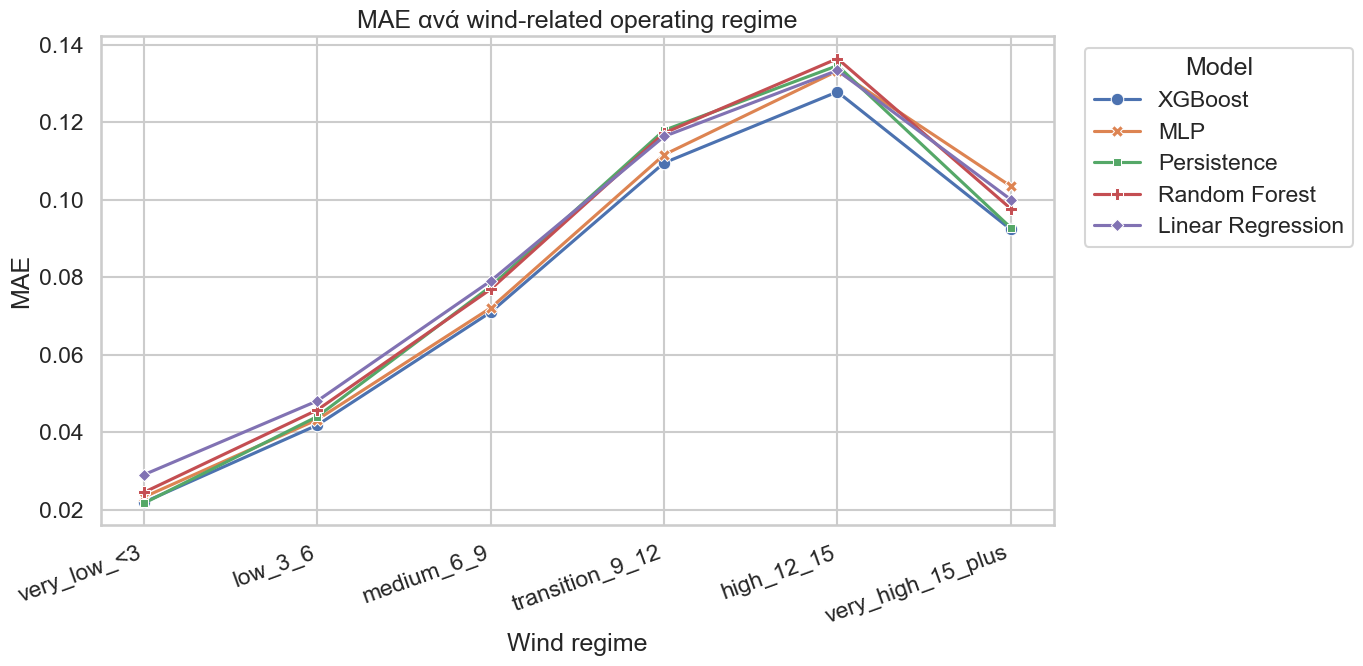

In [18]:
# ============================================================
# NB08 | Plot 1 - MAE by wind regime
# ============================================================

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=wind_summary_df,
    x="wind_regime",
    y="mae",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    hue_order=model_order,
)

plt.title("MAE ανά wind-related operating regime")
plt.xlabel("Wind regime")
plt.ylabel("MAE")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

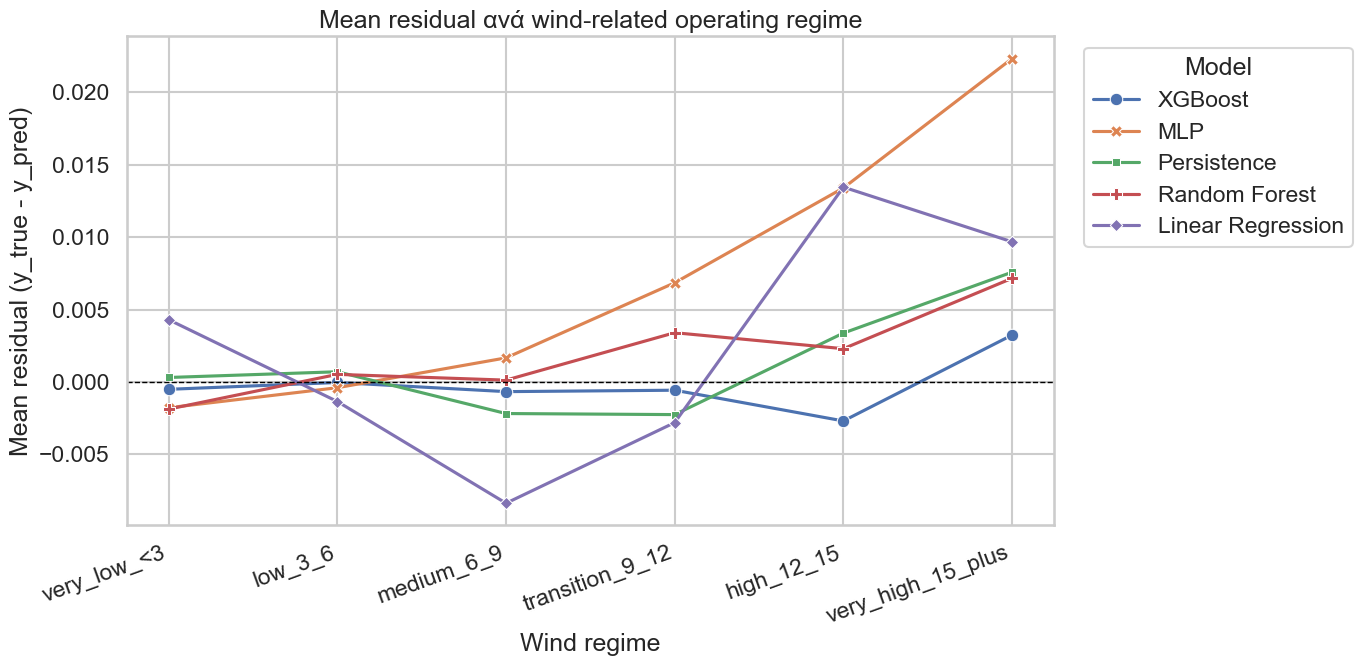

In [19]:
# ============================================================
# NB08 | Plot 2 - Mean signed residual by wind regime
# ============================================================

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=wind_summary_df,
    x="wind_regime",
    y="mean_residual",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    hue_order=model_order,
)

plt.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
plt.title("Mean residual ανά wind-related operating regime")
plt.xlabel("Wind regime")
plt.ylabel("Mean residual (y_true - y_pred)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Ερμηνεία wind-regime diagnostics

Το wind-regime slicing είναι ιδιαίτερα κρίσιμο επειδή η σχέση ανέμου-ισχύος είναι έντονα μη γραμμική.

Αν το error:

- αυξάνεται σε συγκεκριμένες wind-speed zones,
- αλλάζει πρόσημο συστηματικά,
- ή παραμένει δομημένο ακόμη και στους ισχυρότερους baselines,

τότε τα residuals δεν μπορούν να θεωρηθούν απλώς homogeneous aggregate noise.

Αυτό δεν αποδεικνύει turbine fault ή degradation mechanism.  
Δείχνει όμως ότι η residual structure εξαρτάται από την operating envelope του συστήματος.

In [20]:
# ============================================================
# NB08 | Power-regime summaries
# ============================================================

power_summary_df = summarize_by_regime(analysis_df, "power_regime")
power_summary_df.head(15)

,model,power_regime,count,mean_residual,median_residual,mae,rmse
0,XGBoost,near_zero_0_0.05,484038,-0.019929,-0.007702,0.022994,0.046733
1,XGBoost,low_output_0.05_0.25,295107,-0.031702,-0.011529,0.071129,0.107243
2,XGBoost,medium_output_0.25_0.50,121002,0.001576,0.017474,0.123154,0.157196
3,XGBoost,high_output_0.50_0.75,64561,0.082957,0.079061,0.157647,0.197735
4,XGBoost,near_rated_0.75_plus,121628,0.106668,0.054819,0.116961,0.181971
5,MLP,near_zero_0_0.05,484038,-0.020382,-0.009192,0.023619,0.046411
6,MLP,low_output_0.05_0.25,295107,-0.029419,-0.009358,0.071130,0.106492
7,MLP,medium_output_0.25_0.50,121002,0.007179,0.022519,0.122916,0.156614
8,MLP,high_output_0.50_0.75,64561,0.092430,0.089261,0.161285,0.201750
9,MLP,near_rated_0.75_plus,121628,0.125943,0.078226,0.132950,0.191655


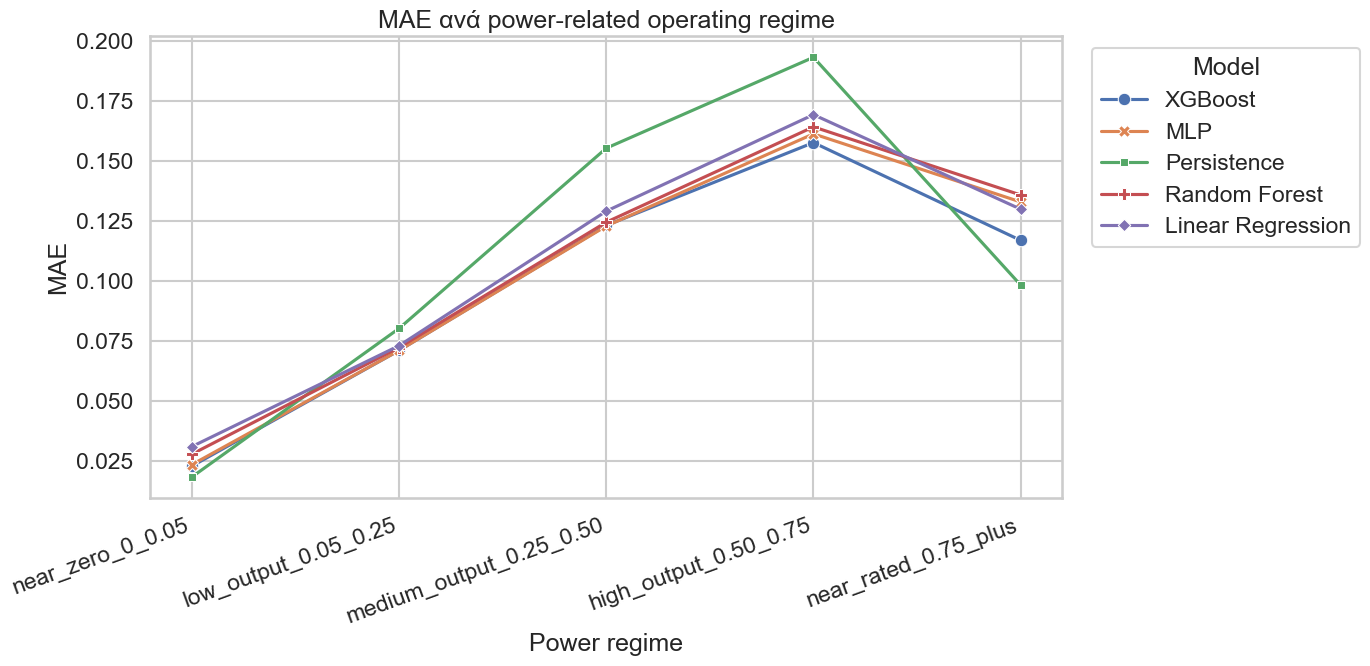

In [21]:
# ============================================================
# NB08 | Plot 3 - MAE by power regime
# ============================================================

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=power_summary_df,
    x="power_regime",
    y="mae",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    hue_order=model_order,
)

plt.title("MAE ανά power-related operating regime")
plt.xlabel("Power regime")
plt.ylabel("MAE")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

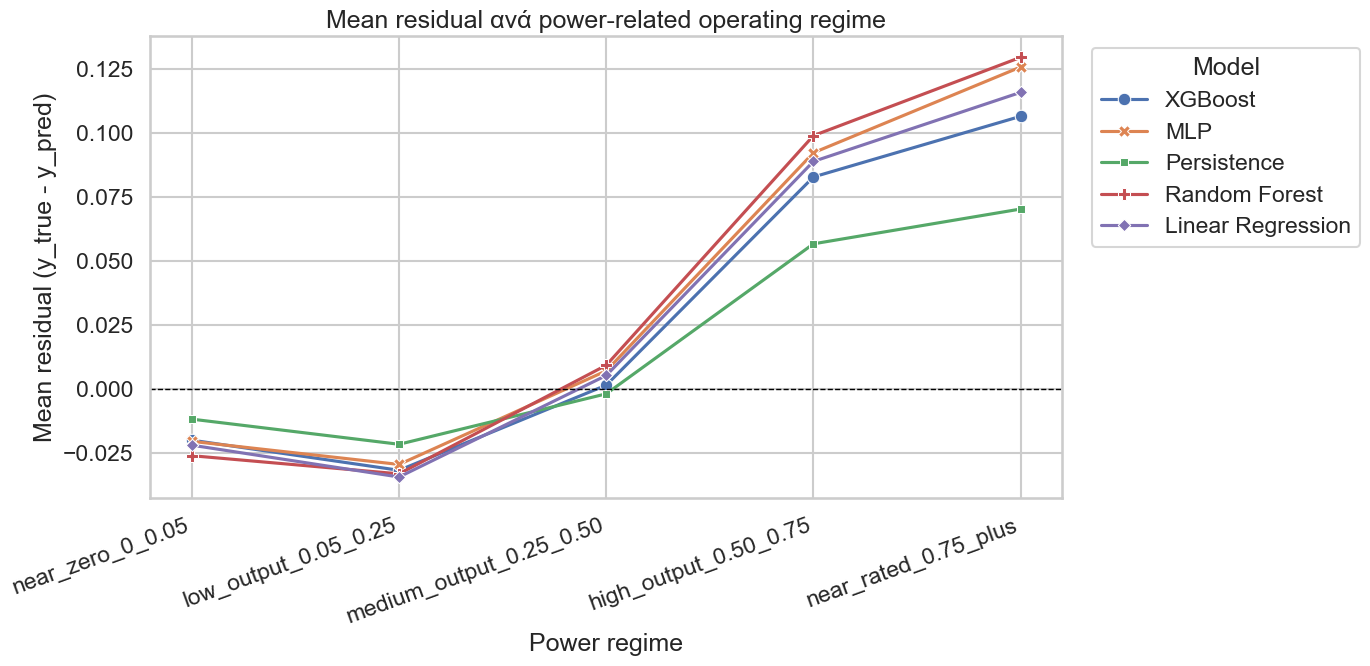

In [22]:
# ============================================================
# NB08 | Plot 4 - Mean signed residual by power regime
# ============================================================

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=power_summary_df,
    x="power_regime",
    y="mean_residual",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    hue_order=model_order,
)

plt.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
plt.title("Mean residual ανά power-related operating regime")
plt.xlabel("Power regime")
plt.ylabel("Mean residual (y_true - y_pred)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Joint operating-regime surface

Η 2D ανάλυση `wind regime × power regime` είναι ιδιαίτερα χρήσιμη γιατί δείχνει αν το error είναι δομημένο μόνο ως προς μία μεταβλητή ή ως προς πιο σύνθετο operating context.

Εδώ δεν χρειάζεται να αναλυθούν όλοι οι models σε heatmaps.  
Για thesis-ready καθαρότητα αρκεί:

- ένα **interpretable reference model** (`Linear Regression`)
- και το **best overall model** σύμφωνα με το current benchmark artifact

In [23]:
# ============================================================
# NB08 | Heatmap helper
# ============================================================

def make_regime_heatmap_table(
    df: pd.DataFrame,
    model_name: str,
    value_col: str = "abs_error",
) -> pd.DataFrame:
    """
    Δημιουργεί 2D table wind_regime x power_regime για ένα model.
    """
    model_df = df.loc[df["model"] == model_name].copy()

    heatmap_table = pd.pivot_table(
        model_df,
        values=value_col,
        index="wind_regime",
        columns="power_regime",
        aggfunc="mean",
        observed=True,
        sort=True,
    )

    return heatmap_table

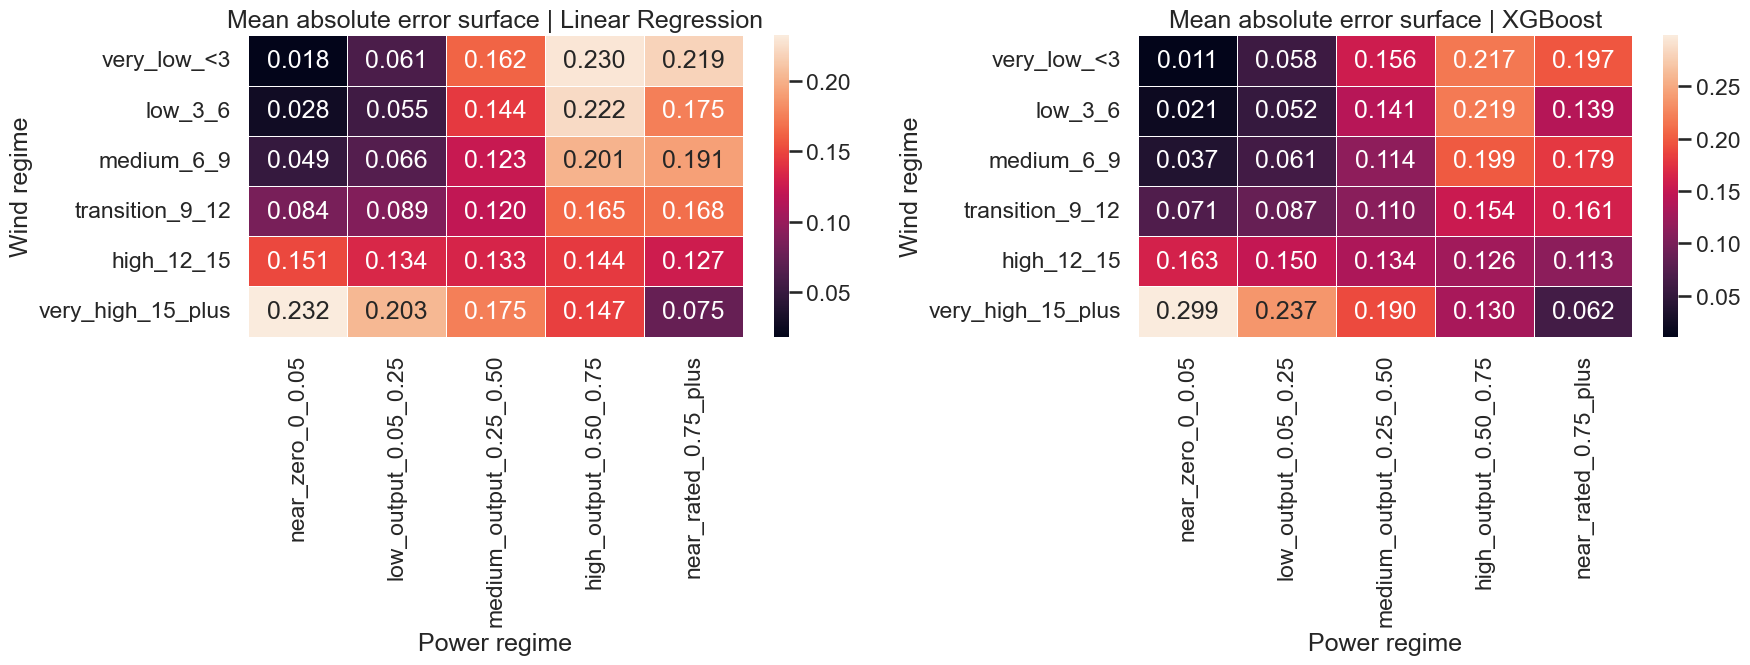

In [24]:
# ============================================================
# NB08 | Plot 5 - Joint wind x power regime heatmaps
# ============================================================

lr_heatmap = make_regime_heatmap_table(analysis_df, linear_reference_model, value_col="abs_error")
best_heatmap = make_regime_heatmap_table(analysis_df, best_overall_model, value_col="abs_error")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    lr_heatmap,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title(f"Mean absolute error surface | {linear_reference_model}")
axes[0].set_xlabel("Power regime")
axes[0].set_ylabel("Wind regime")

sns.heatmap(
    best_heatmap,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title(f"Mean absolute error surface | {best_overall_model}")
axes[1].set_xlabel("Power regime")
axes[1].set_ylabel("Wind regime")

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# NB08 | Regime-wise model ranking tables
# ============================================================

best_by_wind_regime = (
    wind_summary_df.sort_values(["wind_regime", "mae", "rmse"], kind="mergesort")
    .groupby("wind_regime", observed=True, as_index=False)
    .first()[["wind_regime", "model", "mae", "rmse", "mean_residual"]]
    .rename(columns={"model": "best_model_by_mae"})
)

best_by_power_regime = (
    power_summary_df.sort_values(["power_regime", "mae", "rmse"], kind="mergesort")
    .groupby("power_regime", observed=True, as_index=False)
    .first()[["power_regime", "model", "mae", "rmse", "mean_residual"]]
    .rename(columns={"model": "best_model_by_mae"})
)

print("Best model per wind regime")
display(best_by_wind_regime)

print("Best model per power regime")
display(best_by_power_regime)

Best model per wind regime


,wind_regime,best_model_by_mae,mae,rmse,mean_residual
0,very_low_<3,Persistence,0.021639,0.060973,0.000310
1,low_3_6,XGBoost,0.041806,0.078855,-0.000035
2,medium_6_9,XGBoost,0.070959,0.113073,-0.000667
3,transition_9_12,XGBoost,0.109500,0.153881,-0.000569
4,high_12_15,XGBoost,0.127840,0.173796,-0.002692
5,very_high_15_plus,XGBoost,0.092302,0.146609,0.003240


Best model per power regime


,power_regime,best_model_by_mae,mae,rmse,mean_residual
0,near_zero_0_0.05,Persistence,0.018464,0.047634,-0.011709
1,low_output_0.05_0.25,XGBoost,0.071129,0.107243,-0.031702
2,medium_output_0.25_0.50,MLP,0.122916,0.156614,0.007179
3,high_output_0.50_0.75,XGBoost,0.157647,0.197735,0.082957
4,near_rated_0.75_plus,Persistence,0.098357,0.187860,0.070426


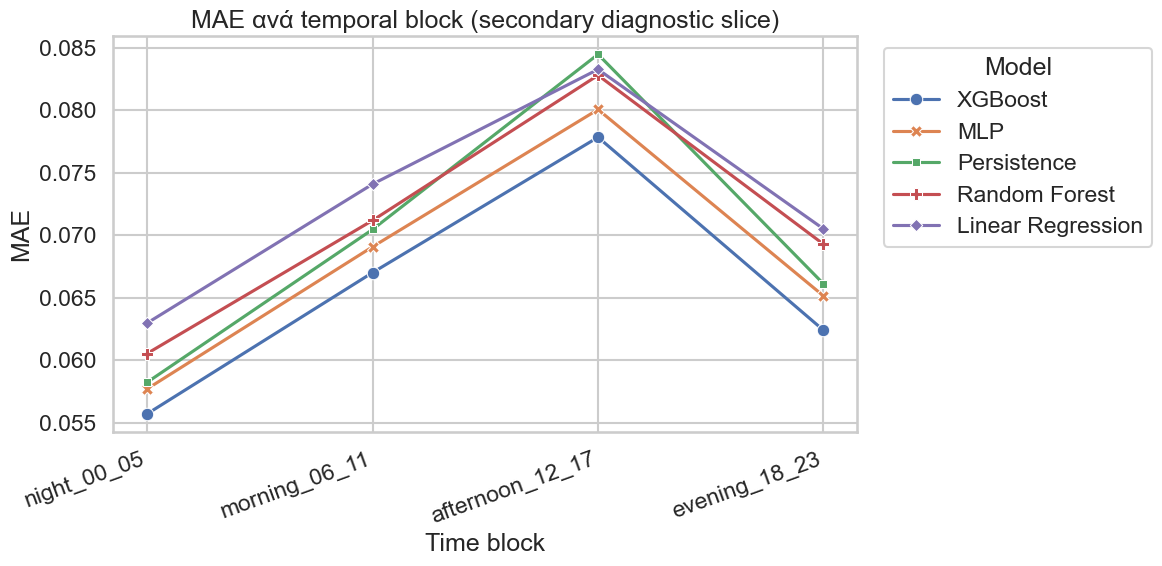

In [26]:
# ============================================================
# NB08 | Secondary temporal diagnostics
# ============================================================

time_summary_df = summarize_by_regime(analysis_df, "time_block")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=time_summary_df,
    x="time_block",
    y="mae",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    hue_order=model_order,
)

plt.title("MAE ανά temporal block (secondary diagnostic slice)")
plt.xlabel("Time block")
plt.ylabel("MAE")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Scientific interpretation

Τα αποτελέσματα του `NB08` δείχνουν ότι τα residuals των baseline forecasting models δεν πρέπει να αντιμετωπίζονται μόνο ως aggregate error.

Αντίθετα, η ανάλυση operating regimes επιτρέπει να εξεταστεί αν:

- η residual magnitude αυξάνεται συστηματικά σε συγκεκριμένες wind-speed zones,
- η bias direction αλλάζει με το operating state,
- και αν η error structure παραμένει παρούσα ακόμη και στους ισχυρότερους non-linear baselines.

Η ύπαρξη τέτοιων patterns δεν αποδεικνύει fault, anomaly class ή degradation mechanism.  
Ωστόσο, δείχνει ότι το forecasting residual μπορεί να αντιμετωπιστεί ως **candidate diagnostic signal** όταν αναλύεται σε συνάρτηση με operating conditions.

Τα ευρήματα αυτά πρέπει να διαβάζονται **συμπληρωματικά** προς το canonical benchmark artifact (`baseline_metrics.csv`) και όχι ως αντικατάσταση του global ranking.  
Με άλλα λόγια, το `NB08` δεν απαντά μόνο στο ερώτημα **ποιο μοντέλο έχει το χαμηλότερο συνολικό MAE**, αλλά και στο ερώτημα **σε ποια operating regimes η residual behavior παραμένει δομημένη**.

Με αυτή την έννοια, το notebook ενισχύει τη σύνδεση του project με:

- health-aware monitoring,
- anomaly awareness,
- operational drift inspection,
- και μελλοντική prognostics / PHM-oriented επέκταση.

Η σύνδεση αυτή παραμένει **προσεκτική και μη υπερβολική**.

## Limitations

Η παρούσα ανάλυση πρέπει να διαβαστεί υπό τους εξής περιορισμούς:

1. Το dataset είναι **synthetic but realistic**, όχι πλήρως real SCADA fault dataset.
2. Τα operating regimes που χρησιμοποιούνται εδώ είναι **proxy regimes** και όχι ακριβή turbine controller states.
3. Δεν υπάρχουν fault labels, maintenance records ή degradation annotations σε αυτό το notebook.
4. Η residual structure δεν αρκεί από μόνη της για:
   - fault diagnosis,
   - anomaly classification,
   - health-state inference,
   - ή RUL estimation.
5. Τα regime-wise findings πρέπει να ερμηνεύονται λαμβάνοντας υπόψη και την **ανισορροπία των regime populations**, ειδικά όπου συγκεκριμένα regimes καλύπτουν μεγαλύτερο μέρος του test space από άλλα.
6. Άρα το output του `NB08` αποτελεί:
   - **diagnostics-aware extension** του forecasting benchmark stack
   - και όχι completed PHM module.

In [27]:
# ============================================================
# NB08 | Compact diagnostics exports
# ============================================================

DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)

wind_summary_export_path = DIAGNOSTICS_DIR / "nb08_wind_regime_metrics.csv"
power_summary_export_path = DIAGNOSTICS_DIR / "nb08_power_regime_metrics.csv"
time_summary_export_path = DIAGNOSTICS_DIR / "nb08_time_block_metrics.csv"
wind_best_export_path = DIAGNOSTICS_DIR / "nb08_best_model_by_wind_regime.csv"
power_best_export_path = DIAGNOSTICS_DIR / "nb08_best_model_by_power_regime.csv"

wind_summary_df.to_csv(wind_summary_export_path, index=False)
power_summary_df.to_csv(power_summary_export_path, index=False)
time_summary_df.to_csv(time_summary_export_path, index=False)
best_by_wind_regime.to_csv(wind_best_export_path, index=False)
best_by_power_regime.to_csv(power_best_export_path, index=False)

print("Compact diagnostics artifacts exported successfully:")
print(f"- {wind_summary_export_path}")
print(f"- {power_summary_export_path}")
print(f"- {time_summary_export_path}")
print(f"- {wind_best_export_path}")
print(f"- {power_best_export_path}")

Compact diagnostics artifacts exported successfully:
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb08_wind_regime_metrics.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb08_power_regime_metrics.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb08_time_block_metrics.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb08_best_model_by_wind_regime.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb08_best_model_by_power_regime.csv


## Συμπέρασμα

Το `NB08` επέκτεινε το current benchmark analysis από το επίπεδο των aggregate metrics στο επίπεδο των **operating-regime-aware residual diagnostics**.

Το βασικό συμπέρασμα είναι ότι το forecasting error δεν είναι ομοιογενές σε όλο το test space.  
Αντίθετα, παρουσιάζει **structured dependence** σε wind-related και power-related operating regimes.

Αυτό έχει σημασία για τη συνολική αφήγηση της πτυχιακής, γιατί δείχνει ότι το implemented forecasting pipeline μπορεί να υποστηρίξει μια πιο explicit σύνδεση με:

- diagnostics-aware monitoring,
- health-aware interpretation,
- και μελλοντική turbine prognostics / health management κατεύθυνση.

Ταυτόχρονα, το notebook παραμένει αυστηρά μεθοδολογικό και δεν υπερβαίνει το τρέχον scope του repository:

- δεν ισχυρίζεται completed PHM system,
- δεν ισχυρίζεται fault diagnosis,
- δεν ισχυρίζεται RUL estimation,
- αλλά θεμελιώνει καθαρά τη γέφυρα:

**forecasting -> residual diagnostics -> health-oriented / PHM-oriented interpretation**

In [28]:
# ============================================================
# NB08 | Final sanity summary
# ============================================================

final_summary = {
    "test_rows": len(test_df),
    "test_columns": test_df.shape[1],
    "test_unique_parks": test_df[PARK_ID_COLUMN].nunique(),
    "combined_prediction_rows": len(all_pred_df),
    "expected_combined_rows": len(test_df) * len(EXPECTED_MODELS),
    "best_overall_model": best_overall_model,
    "wind_regime_count": analysis_df["wind_regime"].nunique(),
    "power_regime_count": analysis_df["power_regime"].nunique(),
    "time_block_count": analysis_df["time_block"].nunique(),
}

pd.Series(final_summary)

test_rows                   1086336
test_columns                     47
test_unique_parks               256
combined_prediction_rows    5431680
expected_combined_rows      5431680
best_overall_model          XGBoost
wind_regime_count                 6
power_regime_count                5
time_block_count                  4
dtype: object